# Malaysia car registrations & EV market (2024-2026)
*Source: [data.gov.my](https://data.gov.my) vehicle registrations. One row = one registered car. 2026 is a partial year.*

In [1]:
# Colab only: fetch the repo's helper code (skipped when run locally)
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('../src'):
    !git clone -q https://github.com/tkongooi/msia-ev-analysis /content/msia-ev-analysis
    !pip install -q pyarrow
    os.chdir('/content/msia-ev-analysis/notebooks')

In [2]:
import sys; sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
from msia_ev import data, analysis as a

df = data.load()          # downloads once, then cached in ../data
upto = a.last_full_month(df)
print(f'{len(df):,} registrations, {df.date_reg.min():%Y-%m-%d} to {df.date_reg.max():%Y-%m-%d}')
df.head()

2,293,041 registrations, 2024-01-01 to 2026-08-31


,date_reg,type,maker,model,colour,fuel,state,year,month,period
0,2024-01-01,jip,Chery,Omoda 5,black,petrol,Rakan Niaga,2024,1,2024-01
1,2024-01-01,jip,Chery,Omoda 5,white,petrol,Rakan Niaga,2024,1,2024-01
2,2024-01-01,jip,Chery,Omoda 5,white,petrol,Rakan Niaga,2024,1,2024-01
3,2024-01-01,pick_up,Ford,Ranger,black,greendiesel,Johor,2024,1,2024-01
4,2024-01-01,pick_up,Ford,Ranger,black,petrol,Johor,2024,1,2024-01


## Key findings
*Computed from the data each time the notebook runs. Growth figures compare the same months (Jan to latest month) of each year.*

In [3]:
from IPython.display import Markdown
ev = a.yoy_same_period(df, df['fuel'] == 'electric')
al = a.yoy_same_period(df)
y0, y1 = ev.index[-2], ev.index[-1]
top = a.top_models(df, year=y1, fuel='electric', n=1).iloc[0]
share = ev['registrations'] / al['registrations'] * 100
Markdown(f'''
- **BEV registrations ({ev.attrs['months']}):** {int(ev.registrations[y1]):,} in {y1}, vs {int(ev.registrations[y0]):,} in {y0} (**{ev.yoy_pct[y1]:+.0f}%**).
- **All cars, same period:** {al.yoy_pct[y1]:+.1f}% YoY, so BEV growth far outpaces the market.
- **BEV share of all registrations:** {share[y1]:.1f}% in {y1}, up from {share[y0]:.1f}% in {y0}.
- **Best-selling BEV in {y1}:** {top.maker} {top.model} ({int(top.registrations):,}).
''')


- **BEV registrations (Jan-8):** 47,508 in 2026, vs 23,396 in 2025 (**+103%**).
- **All cars, same period:** +2.8% YoY, so BEV growth far outpaces the market.
- **BEV share of all registrations:** 8.4% in 2026, up from 4.2% in 2025.
- **Best-selling BEV in 2026:** Proton e.MAS 5 (17,837).


## Market overview: top makers

In [4]:
(df['maker'].value_counts().head(15).to_frame('registrations')
   .assign(share_pct=lambda t: t.registrations / len(df) * 100).round(2))

,registrations,share_pct
maker,,
Perodua,937563,40.89
Proton,434317,18.94
Toyota,329207,14.36
Honda,197913,8.63
Chery,72559,3.16
Mitsubishi,38868,1.70
Mazda,32230,1.41
BYD,30449,1.33
Mercedes Benz,25829,1.13


## EV (BEV) share by month
BEV = `fuel == 'electric'`. Months are kept per-year (the original notebook pooled month numbers across years).

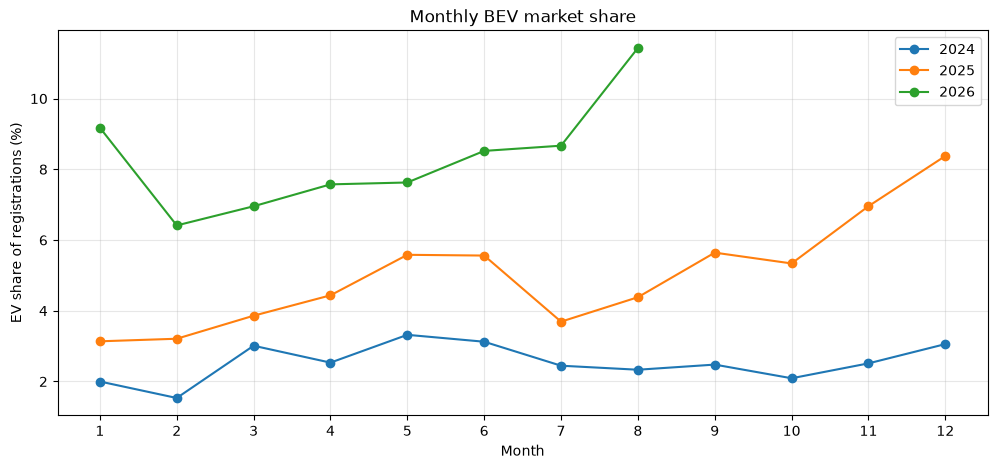

year,2024,2025,2026
month,,,
1,1403,1691,6239
2,1026,2160,3635
3,2260,2976,4717
4,1609,2892,5894
5,2453,4152,5038
6,1912,3272,6215
7,1884,2792,6937
8,1774,3461,8833
9,1513,3532,<NA>


In [5]:
m = a.monthly_ev_share(df)
fig, ax = plt.subplots(figsize=(12, 5))
for y, g in m.groupby('year'):
    ax.plot(g['month'], g['ev_share_pct'], marker='o', label=str(y))
ax.set(xlabel='Month', ylabel='EV share of registrations (%)', title='Monthly BEV market share', xticks=range(1, 13))
ax.legend(); ax.grid(alpha=.3); plt.show()
# months with no data yet are left blank, not shown as 0
m.pivot(index='month', columns='year', values='ev').astype('Int64')

## Year-over-year, like-for-like
Compares Jan to the latest available month of each year (the original compared full-year 2025 with partial 2026, giving a misleading +6%).

In [6]:
r = a.yoy_same_period(df, df['fuel'] == 'electric')
t = a.yoy_same_period(df)
print('BEV registrations,', r.attrs['months'])
r.assign(all_cars=t['registrations'], all_cars_yoy_pct=t['yoy_pct'],
         bev_share_pct=r['registrations'] / t['registrations'] * 100).round(1)

BEV registrations, Jan-8


,registrations,yoy_pct,all_cars,all_cars_yoy_pct,bev_share_pct
year,,,,,
2024,14321,NaN,563892,NaN,2.5
2025,23396,63.4,551365,-2.2,4.2
2026,47508,103.1,566616,2.8,8.4


## Top EV models by year

In [7]:
for y in (2024, 2025, 2026):
    print(f'--- {y}' + (f' (Jan-{upto})' if y == 2026 else ''))
    display(a.top_models(df, year=y, fuel='electric', n=10))

--- 2024


,maker,model,fuel,registrations
0,BYD,Atto 3,electric,2969
1,BYD,Seal,electric,2958
2,Tesla,Model 3,electric,2823
3,Tesla,Model Y,electric,2300
4,BYD,Dolphin,electric,1431
5,BYD,Sealion,electric,641
6,Great Wall,Ora,electric,615
7,Smart,Brabus,electric,602
8,BYD,M6,electric,566
9,Chery,Omoda 5,electric,553


--- 2025


,maker,model,fuel,registrations
0,Proton,e.MAS 7,electric,8677
1,BYD,Sealion,electric,4454
2,Tesla,Model Y,electric,4401
3,BYD,Atto 3,electric,4069
4,Tesla,Model 3,electric,2880
5,BYD,Atto 2,electric,1779
6,BYD,M6,electric,1683
7,Zeekr,7X,electric,1510
8,BYD,Seal 6,electric,1279
9,Denza,D9,electric,1200


--- 2026 (Jan-8)


,maker,model,fuel,registrations
0,Proton,e.MAS 5,electric,17837
1,Proton,e.MAS 7,electric,4004
2,BYD,Atto 3,electric,3027
3,Zeekr,7X,electric,2449
4,Tesla,Model Y,electric,1978
5,Chery,iCaur V23,electric,1812
6,Tesla,Model 3,electric,1755
7,BYD,Sealion,electric,1456
8,BYD,Seal 6,electric,1326
9,BYD,Atto 2,electric,956


## EV maker mix by year

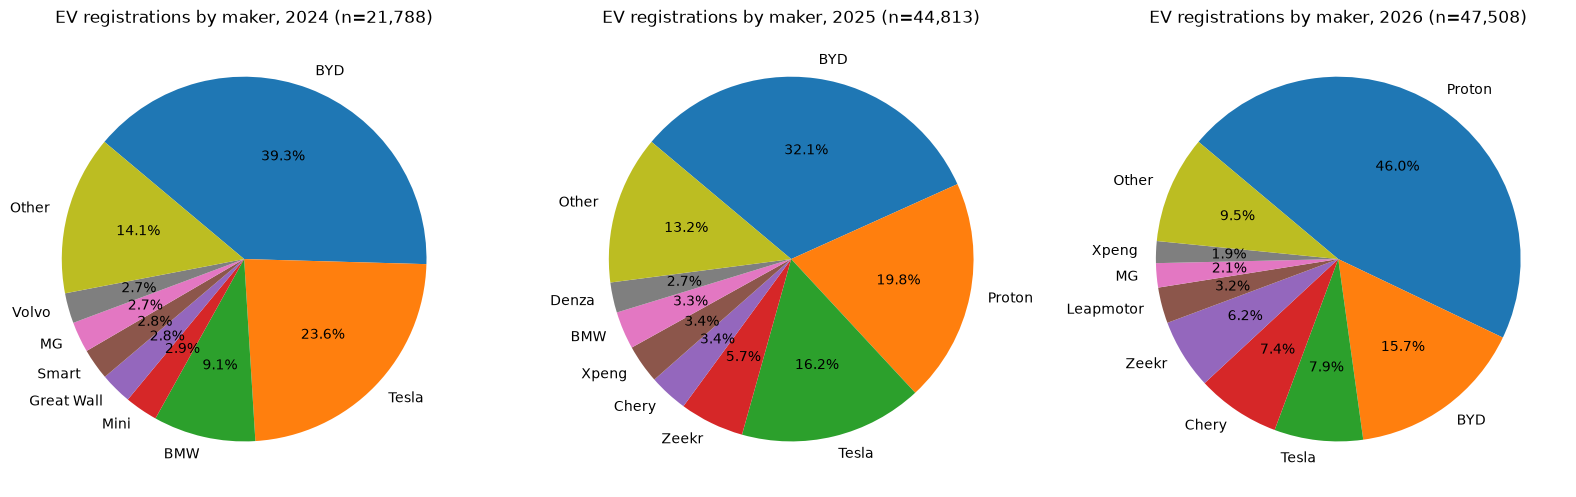

In [8]:
years = (2024, 2025, 2026)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, y in zip(axes, years):
    vc = df[(df.year == y) & (df.fuel == 'electric')]['maker'].value_counts()
    s = vc.head(8)
    s['Other'] = vc.iloc[8:].sum()   # shares are of ALL EV registrations that year
    ax.pie(s, labels=s.index, autopct='%1.1f%%', startangle=140, counterclock=False)
    ax.set_title(f'EV registrations by maker, {y} (n={vc.sum():,})')
plt.show()

## Proton e.MAS 5 vs e.MAS 7, and BYD, by month

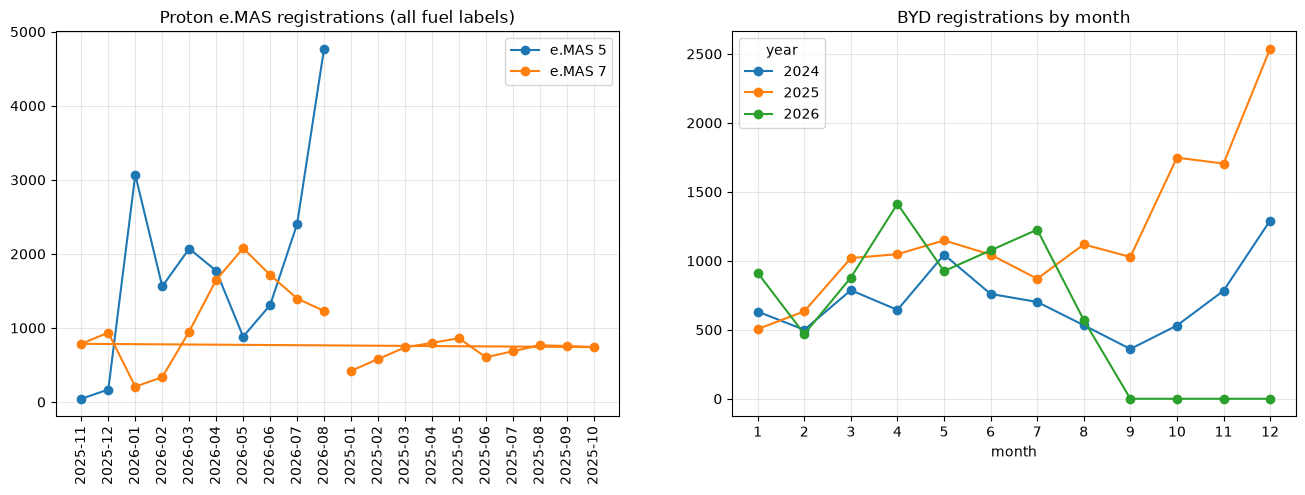

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
em = df[df.maker == 'Proton']
for model in ('e.MAS 5', 'e.MAS 7'):
    s = em[em.model == model].groupby('period').size()
    axes[0].plot(s.index.astype(str), s.values, marker='o', label=model)
axes[0].set_title('Proton e.MAS registrations (all fuel labels)'); axes[0].legend(); axes[0].tick_params(axis='x', rotation=90)
a.monthly_by(df, maker='BYD').plot(ax=axes[1], marker='o', title='BYD registrations by month', xticks=range(1, 13))
for ax in axes: ax.grid(alpha=.3)
plt.show()

## Data caveat: e.MAS 7 appears as both `electric` and `hybrid_petrol`
From Feb 2026 a growing share of e.MAS 7 registrations carry `hybrid_petrol`. This is most likely a **range-extender (EREV) variant** registered as hybrid rather than a mislabel, but the dataset has no variant column so it cannot be confirmed. Treat BEV-only counts of e.MAS 7 as a lower bound.

In [10]:
df[df.model == 'e.MAS 7'].groupby(['period', 'fuel']).size().unstack(fill_value=0).tail(8)

fuel,electric,hybrid_petrol
period,,
2026-01,208,0
2026-02,240,96
2026-03,306,646
2026-04,636,1013
2026-05,896,1181
2026-06,579,1138
2026-07,526,872
2026-08,613,616


## Hybrids
The dataset only has `hybrid_petrol` / `hybrid_diesel`; it cannot separate HEV, PHEV and EREV. (The original PHEV list guessed from luxury model names; dropped as unreliable.)

In [11]:
a.top_models(df, year=2026, fuel=['hybrid_petrol', 'hybrid_diesel'], n=10)

,maker,model,fuel,registrations
0,Proton,e.MAS 7,hybrid_petrol,5562
1,Toyota,Corolla Cross,hybrid_petrol,4129
2,Toyota,Vios,hybrid_petrol,3611
3,Toyota,Yaris Cross,hybrid_petrol,2557
4,Great Wall,Haval H6,hybrid_petrol,2184
5,Great Wall,Wey G9,hybrid_petrol,1769
6,Honda,HR-V,hybrid_petrol,1750
7,Honda,CR-V,hybrid_petrol,1386
8,Nissan,Serena,hybrid_petrol,1274
9,Chery,Tiggo Cross,hybrid_petrol,1163
